
Input data
  Quantified cold sites n = 5
  Sites: Micciano, Libbiano, Palazzo al Piano, Montemiccioli, Occhibolleri
  Cold-site outputs = 1.00-18.60 t/d
  Arithmetic mean = 5.61 t/d
  Geometric mean = 3.10 t/d
  Lognormal fit: mu = 1.133, sigma = 1.169 [log-space]
  Random seed = 42
  Monte Carlo iterations = 30000
  N range = 1-210

Building all-sites Dirichlet-weighted Monte Carlo matrix ...
Building non-parametric bootstrap matrix ...
Building fixed-parametric lognormal matrix ...
Building exceedance-probability grid from all-sites Dirichlet matrix ...
Building leave-one-out Dirichlet-weighted models ...
  Excluding Micciano: n = 4, range = 1.20-18.60 t/d
  Excluding Libbiano: n = 4, range = 1.00-18.60 t/d
  Excluding Palazzo al Piano: n = 4, range = 1.00-18.60 t/d
  Excluding Montemiccioli: n = 4, range = 1.00-4.04 t/d
  Excluding Occhibolleri: n = 4, range = 1.00-18.60 t/d

Output statistics at selected N values
Unsmoothed Monte Carlo statistics; 90% interval = 5th-95th percentil

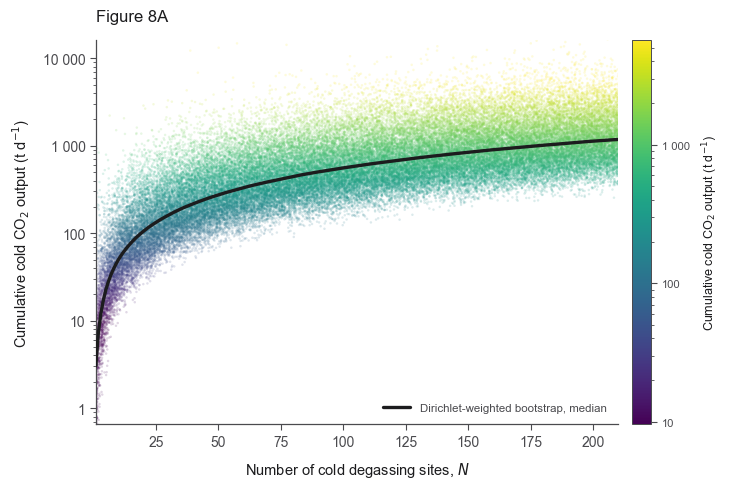

  Saved: figures/Figure_8B_exceedance_probability_contours.pdf
  Saved: figures/Figure_8B_exceedance_probability_contours.svg
  Saved: figures/Figure_8B_exceedance_probability_contours.png
  Saved: figures/Figure_8B_exceedance_probability_contours.tiff


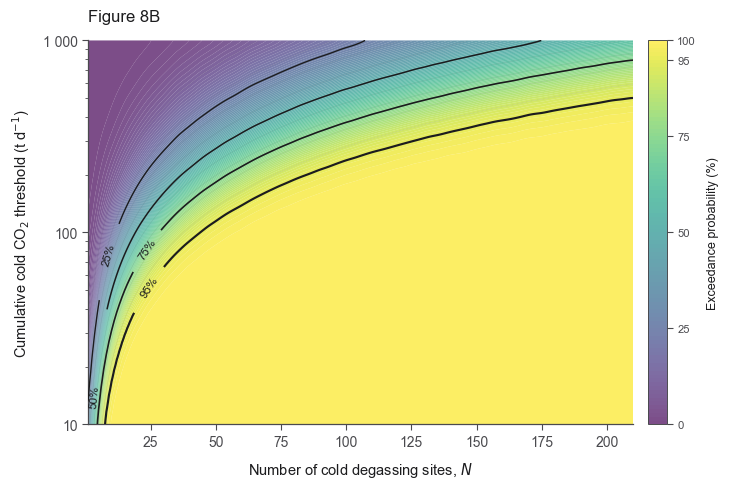

  Saved: figures/Figure_S9A_nonparametric_bootstrap.pdf
  Saved: figures/Figure_S9A_nonparametric_bootstrap.svg
  Saved: figures/Figure_S9A_nonparametric_bootstrap.png
  Saved: figures/Figure_S9A_nonparametric_bootstrap.tiff


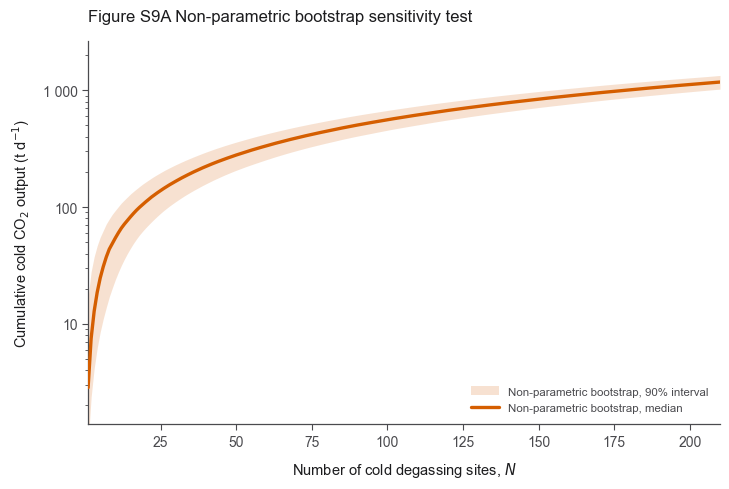

  Saved: figures/Figure_S9B_fixed_parametric_lognormal.pdf
  Saved: figures/Figure_S9B_fixed_parametric_lognormal.svg
  Saved: figures/Figure_S9B_fixed_parametric_lognormal.png
  Saved: figures/Figure_S9B_fixed_parametric_lognormal.tiff


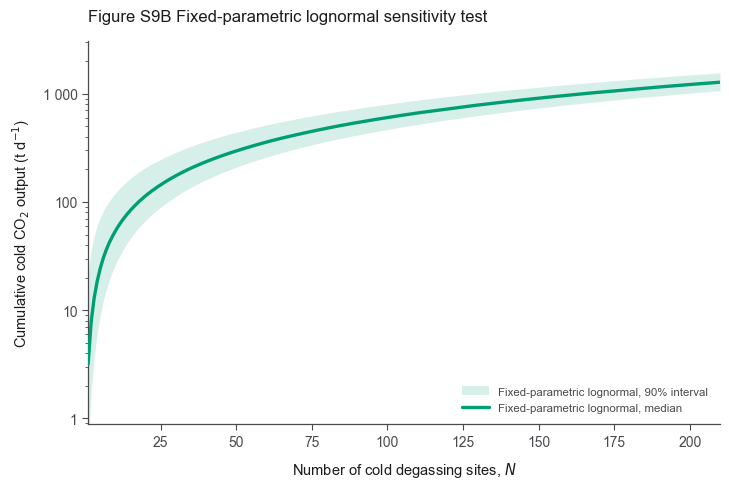

  Saved: figures/Figure_S9C_leave_one_out_sensitivity.pdf
  Saved: figures/Figure_S9C_leave_one_out_sensitivity.svg
  Saved: figures/Figure_S9C_leave_one_out_sensitivity.png
  Saved: figures/Figure_S9C_leave_one_out_sensitivity.tiff


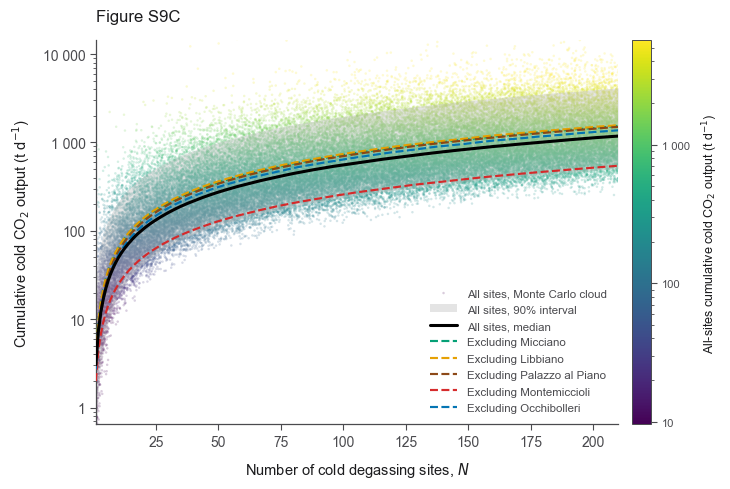

In [3]:
"""
Monte Carlo upscaling of cold CO2 degassing in the Tuscan sector
of the Northern Apennines back-arc.

Author:
    A. Rielli, National Research Council of Italy

Figures:
    Figure 8A   Dirichlet-weighted bootstrap point cloud and median
    Figure 8B   Exceedance-probability contours
    Figure S9A  Non-parametric bootstrap sensitivity test
    Figure S9B  Fixed-lognormal sensitivity test
    Figure S9C  Leave-one-out Dirichlet-weighted sensitivity test

Data:
    Site-integrated cold CO2 outputs from Micciano, Montemiccioli, Libbiano
    and Palazzo al Piano after Taussi et al. (2023), and Occhibolleri from
    this study.

Notes:
    Monte Carlo uncertainty is reported as the 5th-95th percentile range.
    Curves and probability contours are smoothed for plotting only.
    Printed statistics are calculated from the unsmoothed Monte Carlo outputs.
    Point clouds are horizontally jittered only for visualisation.
"""

from __future__ import annotations

import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib as mpl


# ---------------------------------------------------------------------------
# Configuration
# ---------------------------------------------------------------------------

RNG_SEED = 42
N_ITER = 30000

N_POINTS_SHOWN = 300

# Use 164 for the manuscript inventory.
# Use 210 only for exploratory plots beyond the current inventory.
N_MAX = 210
N_ALL = np.arange(1, N_MAX + 1)

N_TARGETS = [30, 100, 200]

JITTER_WIDTH = 0.60

POINT_SIZE = 3.2
POINT_ALPHA_8A = 0.16
POINT_ALPHA_S9C = 0.20
RASTERIZED_POINTS = False

SMOOTH_WINDOW_MAIN = 7
SMOOTH_WINDOW_S9 = 9

OUTPUT_DIR = "figures"
PNG_DPI = 600

# Reference value used only for printed diagnostics in S9C.
LARDERELLO_REFERENCE_TD = 14.4

THRESHOLD_MIN = 10.0
THRESHOLD_MAX = 1000.0
N_THRESHOLDS = 300

THRESHOLDS = np.geomspace(
    THRESHOLD_MIN,
    THRESHOLD_MAX,
    N_THRESHOLDS,
)

MINOR_CONTOUR_LEVELS = [10, 20, 30, 40, 60, 70, 80, 90]
MAIN_CONTOUR_LEVELS = [25, 50, 75]
HIGH_CONTOUR_LEVEL = [95]

SMOOTH_SIGMA_THRESHOLD = 3.0
SMOOTH_SIGMA_N = 2.0

FIELD_ALPHA = 0.70


# ---------------------------------------------------------------------------
# Input data
# ---------------------------------------------------------------------------

COLD_SITES = {
    "Micciano": 1.0,
    "Libbiano": 1.2,
    "Palazzo al Piano": 3.2,
    "Montemiccioli": 18.6,
    "Occhibolleri": 4.04,
}


# ---------------------------------------------------------------------------
# Style
# ---------------------------------------------------------------------------

INK = "#1C1C1E"
INK_SOFT = "#4A4A4E"
PAPER = "#FFFFFF"

C_DIRICHLET = "#1C1C1E"
C_BOOT = "#D55E00"
C_PAR = "#009E73"

CMAP = plt.get_cmap("viridis")

LOO_COLOURS = {
    "Micciano": "#009E73",
    "Libbiano": "#E69F00",
    "Palazzo al Piano": "#8B4513",
    "Montemiccioli": "#D62728",
    "Occhibolleri": "#0072B2",
}

FONT_STACK = ["Arial", "Helvetica", "DejaVu Sans"]


# ---------------------------------------------------------------------------
# Monte Carlo
# ---------------------------------------------------------------------------

def fit_lognormal(values: np.ndarray) -> tuple[float, float]:
    log_values = np.log(values)
    mu = float(log_values.mean())
    sigma = float(log_values.std(ddof=1))
    return mu, sigma


def sample_totals_dirichlet_weighted(
    cold: np.ndarray,
    N: int,
    n_iter: int,
    rng: np.random.Generator,
) -> np.ndarray:
    log_cold = np.log(cold)
    n_sites = cold.size

    weights = rng.dirichlet(
        alpha=np.ones(n_sites),
        size=n_iter,
    )

    mu_iter = (weights * log_cold[None, :]).sum(axis=1)

    diffs = log_cold[None, :] - mu_iter[:, None]
    weighted_var = (weights * diffs**2).sum(axis=1)

    correction = 1.0 / (1.0 - np.sum(weights**2, axis=1))
    sigma_iter = np.sqrt(weighted_var * correction)

    draws = rng.lognormal(
        mean=mu_iter[:, None],
        sigma=sigma_iter[:, None],
        size=(n_iter, N),
    )

    return draws.sum(axis=1)


def sample_totals_bootstrap(
    cold: np.ndarray,
    N: int,
    n_iter: int,
    rng: np.random.Generator,
) -> np.ndarray:
    draws = rng.choice(
        cold,
        size=(n_iter, N),
        replace=True,
    )

    return draws.sum(axis=1)


def sample_totals_parametric(
    mu: float,
    sigma: float,
    N: int,
    n_iter: int,
    rng: np.random.Generator,
) -> np.ndarray:
    draws = rng.lognormal(
        mean=mu,
        sigma=sigma,
        size=(n_iter, N),
    )

    return draws.sum(axis=1)


def build_totals_matrix(
    scheme: str,
    cold: np.ndarray,
    n_iter: int,
    rng: np.random.Generator,
) -> np.ndarray:
    """
    Build one Monte Carlo output matrix.

    Shape:
        rows = N = 1...N_MAX
        columns = Monte Carlo realisations
    """
    mu, sigma = fit_lognormal(cold)

    totals_matrix = np.empty(
        (N_MAX, n_iter),
        dtype=np.float32,
    )

    for i, N in enumerate(N_ALL):
        if scheme == "dirichlet":
            totals = sample_totals_dirichlet_weighted(
                cold=cold,
                N=int(N),
                n_iter=n_iter,
                rng=rng,
            )

        elif scheme == "bootstrap":
            totals = sample_totals_bootstrap(
                cold=cold,
                N=int(N),
                n_iter=n_iter,
                rng=rng,
            )

        elif scheme == "parametric":
            totals = sample_totals_parametric(
                mu=mu,
                sigma=sigma,
                N=int(N),
                n_iter=n_iter,
                rng=rng,
            )

        else:
            raise ValueError(f"Unknown scheme: {scheme}")

        totals_matrix[i, :] = totals.astype(np.float32)

    return totals_matrix


def summary_from_totals(
    totals_matrix: np.ndarray,
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    p5, med, p95 = np.percentile(
        totals_matrix,
        [5, 50, 95],
        axis=1,
    )

    return p5, med, p95


def cloud_from_totals(
    totals_matrix: np.ndarray,
    n_shown: int,
    rng: np.random.Generator,
) -> tuple[np.ndarray, np.ndarray]:
    xs = []
    ys = []

    n_iter = totals_matrix.shape[1]

    for i, N in enumerate(N_ALL):
        idx = rng.choice(
            n_iter,
            size=min(n_shown, n_iter),
            replace=False,
        )

        x_values = N + rng.uniform(
            low=-JITTER_WIDTH,
            high=JITTER_WIDTH,
            size=len(idx),
        )

        y_values = totals_matrix[i, idx]

        xs.append(x_values)
        ys.append(y_values)

    return np.concatenate(xs), np.concatenate(ys)


def probability_grid_from_totals(
    totals_matrix: np.ndarray,
    thresholds: np.ndarray,
) -> np.ndarray:
    probability_grid = np.empty(
        (thresholds.size, totals_matrix.shape[0]),
        dtype=float,
    )

    for j in range(totals_matrix.shape[0]):
        totals = totals_matrix[j, :]
        probability_grid[:, j] = (
            np.mean(totals[None, :] > thresholds[:, None], axis=1) * 100.0
        )

    return probability_grid


# ---------------------------------------------------------------------------
# Smoothing
# ---------------------------------------------------------------------------

def smooth_curve_logspace(
    values: np.ndarray,
    window: int = 9,
) -> np.ndarray:
    values = np.asarray(values, dtype=float)

    if np.any(values <= 0):
        raise ValueError("All values must be positive for log-space smoothing.")

    if window <= 1:
        return values.copy()

    if window % 2 == 0:
        window += 1

    half_window = window // 2

    x = np.log(N_ALL.astype(float))
    y = np.log(values)

    y_smooth = np.empty_like(y)

    for i in range(len(y)):
        i0 = max(0, i - half_window)
        i1 = min(len(y), i + half_window + 1)

        x_local = x[i0:i1]
        y_local = y[i0:i1]

        if len(x_local) >= 2:
            coeff = np.polyfit(x_local, y_local, deg=1)
            y_smooth[i] = np.polyval(coeff, x[i])
        else:
            y_smooth[i] = y[i]

    return np.exp(y_smooth)


def smooth_interval_logspace(
    p5: np.ndarray,
    med: np.ndarray,
    p95: np.ndarray,
    window: int = 9,
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    p5_s = smooth_curve_logspace(p5, window=window)
    med_s = smooth_curve_logspace(med, window=window)
    p95_s = smooth_curve_logspace(p95, window=window)

    p5_s = np.minimum(p5_s, med_s)
    p95_s = np.maximum(p95_s, med_s)

    return p5_s, med_s, p95_s


def smooth_probability_grid(
    grid: np.ndarray,
    sigma_threshold: float = 3.0,
    sigma_n: float = 2.0,
) -> np.ndarray:

    def gaussian_kernel1d(sigma: float) -> np.ndarray:
        if sigma <= 0:
            return np.array([1.0])

        radius = int(np.ceil(3 * sigma))
        x = np.arange(-radius, radius + 1)

        kernel = np.exp(-(x**2) / (2 * sigma**2))
        kernel /= kernel.sum()

        return kernel

    def convolve_along_axis(
        array: np.ndarray,
        kernel: np.ndarray,
        axis: int,
    ) -> np.ndarray:
        pad = len(kernel) // 2

        pad_width = [(0, 0)] * array.ndim
        pad_width[axis] = (pad, pad)

        padded = np.pad(
            array,
            pad_width=pad_width,
            mode="edge",
        )

        return np.apply_along_axis(
            lambda m: np.convolve(m, kernel, mode="valid"),
            axis=axis,
            arr=padded,
        )

    smoothed = grid.copy()

    smoothed = convolve_along_axis(
        smoothed,
        gaussian_kernel1d(sigma_threshold),
        axis=0,
    )

    smoothed = convolve_along_axis(
        smoothed,
        gaussian_kernel1d(sigma_n),
        axis=1,
    )

    return np.clip(smoothed, 0.0, 100.0)


# ---------------------------------------------------------------------------
# Plotting utilities
# ---------------------------------------------------------------------------

def full_number_formatter(value: float, _: int | None = None) -> str:
    return f"{value:,.0f}".replace(",", " ")


def set_plot_style() -> None:
    plt.rcParams.update({
        "font.family": "sans-serif",
        "font.sans-serif": FONT_STACK,
        "font.size": 10,
        "text.color": INK,
        "axes.edgecolor": INK_SOFT,
        "axes.labelcolor": INK,
        "axes.linewidth": 0.9,
        "axes.facecolor": PAPER,
        "figure.facecolor": PAPER,
        "savefig.facecolor": PAPER,
        "xtick.color": INK_SOFT,
        "ytick.color": INK_SOFT,
        "xtick.direction": "out",
        "ytick.direction": "out",
        "xtick.major.size": 4,
        "ytick.major.size": 4,
        "ytick.minor.size": 2.2,
        "axes.axisbelow": True,
        "svg.fonttype": "none",
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
    })


def save_figure(fig: plt.Figure, filename_base: str) -> None:
    os.makedirs(OUTPUT_DIR, exist_ok=True)

    pdf_path = os.path.join(OUTPUT_DIR, f"{filename_base}.pdf")
    svg_path = os.path.join(OUTPUT_DIR, f"{filename_base}.svg")
    png_path = os.path.join(OUTPUT_DIR, f"{filename_base}.png")
    tiff_path = os.path.join(OUTPUT_DIR, f"{filename_base}.tiff")

    fig.savefig(pdf_path, bbox_inches="tight")
    fig.savefig(svg_path, bbox_inches="tight")
    fig.savefig(png_path, dpi=PNG_DPI, bbox_inches="tight")
    fig.savefig(tiff_path, dpi=PNG_DPI, bbox_inches="tight")

    print(f"  Saved: {pdf_path}")
    print(f"  Saved: {svg_path}")
    print(f"  Saved: {png_path}")
    print(f"  Saved: {tiff_path}")


def format_output_axes(ax: plt.Axes, title: str) -> None:
    ax.set_yscale("log")
    ax.set_xlim(1, N_MAX)

    ax.set_xlabel(
        "Number of cold degassing sites, $N$",
        fontsize=10.5,
        labelpad=8,
    )

    ax.set_ylabel(
        "Cumulative cold CO$_2$ output (t d$^{-1}$)",
        fontsize=10.5,
        labelpad=8,
    )

    ax.yaxis.set_major_locator(mticker.LogLocator(base=10))
    ax.yaxis.set_minor_locator(
        mticker.LogLocator(
            base=10,
            subs=np.arange(2, 10) * 0.1,
        )
    )

    ax.yaxis.set_major_formatter(
        mticker.FuncFormatter(full_number_formatter)
    )

    ax.grid(False)

    for spine_name in ("top", "right"):
        ax.spines[spine_name].set_visible(False)

    for spine_name in ("left", "bottom"):
        ax.spines[spine_name].set_color(INK_SOFT)
        ax.spines[spine_name].set_linewidth(0.9)

    ax.set_title(
        title,
        fontsize=12,
        fontweight="medium",
        color=INK,
        pad=14,
        loc="left",
    )


def format_threshold_axis(ax: plt.Axes) -> None:
    ax.set_yscale("log")

    ax.yaxis.set_major_locator(mticker.LogLocator(base=10))
    ax.yaxis.set_minor_locator(
        mticker.LogLocator(
            base=10,
            subs=np.arange(2, 10) * 0.1,
        )
    )

    ax.yaxis.set_major_formatter(
        mticker.FuncFormatter(full_number_formatter)
    )


def clean_legend(ax: plt.Axes, loc: str = "lower right") -> None:
    leg = ax.legend(
        loc=loc,
        frameon=True,
        fontsize=8.3,
        handlelength=2.4,
        labelspacing=0.55,
        borderaxespad=0.6,
        framealpha=1.0,
        facecolor=PAPER,
        edgecolor="none",
    )

    for text in leg.get_texts():
        text.set_color(INK_SOFT)


def add_log_colourbar(
    fig: plt.Figure,
    ax: plt.Axes,
    cloud_norm: mpl.colors.LogNorm,
    label: str,
) -> None:
    cbar_mappable = mpl.cm.ScalarMappable(
        norm=cloud_norm,
        cmap=CMAP,
    )
    cbar_mappable.set_array([])

    cbar = fig.colorbar(
        cbar_mappable,
        ax=ax,
        pad=0.025,
        fraction=0.045,
    )

    cbar.set_label(
        label,
        fontsize=9,
        color=INK,
        labelpad=8,
    )

    cbar.ax.tick_params(
        labelsize=8,
        colors=INK_SOFT,
    )

    cbar.ax.yaxis.set_major_formatter(
        mticker.FuncFormatter(full_number_formatter)
    )

    cbar.outline.set_edgecolor(INK_SOFT)
    cbar.outline.set_linewidth(0.7)


# ---------------------------------------------------------------------------
# Figures
# ---------------------------------------------------------------------------

def make_figure_8a(
    xy_dirichlet: tuple[np.ndarray, np.ndarray],
    med_dirichlet: np.ndarray,
    save: bool = False,
) -> None:
    set_plot_style()

    fig, ax = plt.subplots(figsize=(7.4, 5.0))

    x_cloud, y_cloud = xy_dirichlet

    cloud_norm = mpl.colors.LogNorm(
        vmin=max(0.1, np.percentile(y_cloud, 1)),
        vmax=np.percentile(y_cloud, 99.5),
    )

    ax.scatter(
        x_cloud,
        y_cloud,
        s=POINT_SIZE,
        c=y_cloud,
        cmap=CMAP,
        norm=cloud_norm,
        alpha=POINT_ALPHA_8A,
        linewidths=0,
        rasterized=RASTERIZED_POINTS,
        zorder=2,
    )

    med_plot = smooth_curve_logspace(
        med_dirichlet,
        window=SMOOTH_WINDOW_MAIN,
    )

    ax.plot(
        N_ALL,
        med_plot,
        color=C_DIRICHLET,
        lw=2.4,
        zorder=5,
        label="Dirichlet-weighted bootstrap, median",
        solid_capstyle="round",
    )

    all_y = np.concatenate([y_cloud, med_plot])

    ax.set_ylim(
        max(0.5, np.percentile(all_y, 0.05)),
        np.percentile(all_y, 99.85) * 2.0,
    )

    format_output_axes(ax, title="Figure 8A")

    add_log_colourbar(
        fig=fig,
        ax=ax,
        cloud_norm=cloud_norm,
        label="Cumulative cold CO$_2$ output (t d$^{-1}$)",
    )

    clean_legend(ax)

    fig.tight_layout()

    if save:
        save_figure(fig, "Figure_8A_dirichlet_weighted_cloud")

    plt.show()


def make_figure_8b(
    probability_grid: np.ndarray,
    thresholds: np.ndarray,
    save: bool = False,
) -> None:
    set_plot_style()

    fig, ax = plt.subplots(figsize=(7.4, 5.0))

    N_grid, threshold_grid = np.meshgrid(N_ALL, thresholds)

    probability_grid_plot = smooth_probability_grid(
        probability_grid,
        sigma_threshold=SMOOTH_SIGMA_THRESHOLD,
        sigma_n=SMOOTH_SIGMA_N,
    )

    background = ax.contourf(
        N_grid,
        threshold_grid,
        probability_grid_plot,
        levels=np.linspace(0, 100, 101),
        cmap=CMAP,
        alpha=FIELD_ALPHA,
        antialiased=True,
        zorder=1,
    )

    ax.contour(
        N_grid,
        threshold_grid,
        probability_grid_plot,
        levels=MINOR_CONTOUR_LEVELS,
        colors=INK,
        linewidths=0.30,
        alpha=0.13,
        zorder=3,
    )

    main_contours = ax.contour(
        N_grid,
        threshold_grid,
        probability_grid_plot,
        levels=MAIN_CONTOUR_LEVELS,
        colors=INK,
        linewidths=[1.00, 1.10, 1.20],
        zorder=4,
    )

    labels_main = ax.clabel(
        main_contours,
        fmt={25: "25%", 50: "50%", 75: "75%"},
        fontsize=8.4,
        colors=INK,
        inline=True,
        inline_spacing=5,
        rightside_up=True,
        use_clabeltext=True,
    )

    contour_95 = ax.contour(
        N_grid,
        threshold_grid,
        probability_grid_plot,
        levels=HIGH_CONTOUR_LEVEL,
        colors=INK,
        linewidths=1.55,
        zorder=5,
    )

    labels_95 = ax.clabel(
        contour_95,
        fmt={95: "95%"},
        fontsize=8.4,
        colors=INK,
        inline=True,
        inline_spacing=5,
        rightside_up=True,
        use_clabeltext=True,
    )

    for label in list(labels_main) + list(labels_95):
        label.set_color(INK)
        label.set_fontsize(8.4)
        label.set_rotation_mode("anchor")

    ax.set_xlim(1, N_MAX)
    ax.set_ylim(THRESHOLD_MIN, THRESHOLD_MAX)

    format_threshold_axis(ax)

    ax.set_xlabel(
        "Number of cold degassing sites, $N$",
        fontsize=10.5,
        labelpad=8,
    )

    ax.set_ylabel(
        "Cumulative cold CO$_2$ threshold (t d$^{-1}$)",
        fontsize=10.5,
        labelpad=8,
    )

    ax.set_title(
        "Figure 8B",
        fontsize=12,
        fontweight="medium",
        color=INK,
        pad=14,
        loc="left",
    )

    cbar = fig.colorbar(
        background,
        ax=ax,
        pad=0.025,
        fraction=0.045,
    )

    cbar.set_label(
        "Exceedance probability (%)",
        fontsize=9,
        color=INK,
        labelpad=8,
    )

    cbar.set_ticks([0, 25, 50, 75, 95, 100])

    cbar.ax.tick_params(
        labelsize=8,
        colors=INK_SOFT,
    )

    cbar.outline.set_edgecolor(INK_SOFT)
    cbar.outline.set_linewidth(0.7)

    for spine_name in ("top", "right"):
        ax.spines[spine_name].set_visible(False)

    for spine_name in ("left", "bottom"):
        ax.spines[spine_name].set_color(INK_SOFT)
        ax.spines[spine_name].set_linewidth(0.9)

    ax.grid(False)

    fig.tight_layout()

    if save:
        save_figure(fig, "Figure_8B_exceedance_probability_contours")

    plt.show()


def make_figure_s9a(
    p5_boot: np.ndarray,
    med_boot: np.ndarray,
    p95_boot: np.ndarray,
    save: bool = False,
) -> None:
    set_plot_style()

    p5_s, med_s, p95_s = smooth_interval_logspace(
        p5_boot,
        med_boot,
        p95_boot,
        window=SMOOTH_WINDOW_S9,
    )

    fig, ax = plt.subplots(figsize=(7.4, 5.0))

    ax.fill_between(
        N_ALL,
        p5_s,
        p95_s,
        color=C_BOOT,
        alpha=0.18,
        linewidth=0,
        zorder=1,
        label="Non-parametric bootstrap, 90% interval",
    )

    ax.plot(
        N_ALL,
        med_s,
        color=C_BOOT,
        lw=2.4,
        zorder=5,
        label="Non-parametric bootstrap, median",
        solid_capstyle="round",
    )

    all_y = np.concatenate([p5_s, med_s, p95_s])

    ax.set_ylim(
        max(0.5, np.percentile(all_y, 0.05)),
        np.percentile(all_y, 99.85) * 2.0,
    )

    format_output_axes(
        ax,
        title="Figure S9A Non-parametric bootstrap sensitivity test",
    )

    clean_legend(ax)

    fig.tight_layout()

    if save:
        save_figure(fig, "Figure_S9A_nonparametric_bootstrap")

    plt.show()


def make_figure_s9b(
    p5_par: np.ndarray,
    med_par: np.ndarray,
    p95_par: np.ndarray,
    save: bool = False,
) -> None:
    set_plot_style()

    p5_s, med_s, p95_s = smooth_interval_logspace(
        p5_par,
        med_par,
        p95_par,
        window=SMOOTH_WINDOW_S9,
    )

    fig, ax = plt.subplots(figsize=(7.4, 5.0))

    ax.fill_between(
        N_ALL,
        p5_s,
        p95_s,
        color=C_PAR,
        alpha=0.16,
        linewidth=0,
        zorder=1,
        label="Fixed-parametric lognormal, 90% interval",
    )

    ax.plot(
        N_ALL,
        med_s,
        color=C_PAR,
        lw=2.4,
        zorder=5,
        label="Fixed-parametric lognormal, median",
        solid_capstyle="round",
    )

    all_y = np.concatenate([p5_s, med_s, p95_s])

    ax.set_ylim(
        max(0.5, np.percentile(all_y, 0.05)),
        np.percentile(all_y, 99.85) * 2.0,
    )

    format_output_axes(
        ax,
        title="Figure S9B Fixed-parametric lognormal sensitivity test",
    )

    clean_legend(ax)

    fig.tight_layout()

    if save:
        save_figure(fig, "Figure_S9B_fixed_parametric_lognormal")

    plt.show()


def make_figure_s9c(
    xy_all: tuple[np.ndarray, np.ndarray],
    p5_all: np.ndarray,
    med_all: np.ndarray,
    p95_all: np.ndarray,
    loo_results: dict[str, dict[str, np.ndarray | str]],
    save: bool = False,
) -> None:
    set_plot_style()

    fig, ax = plt.subplots(figsize=(7.4, 5.0))

    x_all, y_all = xy_all

    cloud_norm = mpl.colors.LogNorm(
        vmin=max(0.1, np.percentile(y_all, 1)),
        vmax=np.percentile(y_all, 99.5),
    )

    p5_all_s, med_all_s, p95_all_s = smooth_interval_logspace(
        p5_all,
        med_all,
        p95_all,
        window=SMOOTH_WINDOW_S9,
    )

    ax.scatter(
        x_all,
        y_all,
        s=POINT_SIZE,
        c=y_all,
        cmap=CMAP,
        norm=cloud_norm,
        alpha=POINT_ALPHA_S9C,
        linewidths=0,
        rasterized=RASTERIZED_POINTS,
        zorder=1,
        label="All sites, Monte Carlo cloud",
    )

    ax.fill_between(
        N_ALL,
        p5_all_s,
        p95_all_s,
        color="0.75",
        alpha=0.42,
        linewidth=0,
        zorder=2,
        label="All sites, 90% interval",
    )

    ax.plot(
        N_ALL,
        med_all_s,
        color="black",
        lw=2.2,
        zorder=8,
        label="All sites, median",
        solid_capstyle="round",
    )

    for excluded_site, res in loo_results.items():
        med_loo_s = smooth_curve_logspace(
            res["med"],
            window=SMOOTH_WINDOW_S9,
        )

        ax.plot(
            N_ALL,
            med_loo_s,
            color=res["colour"],
            lw=1.55,
            ls="--",
            alpha=0.98,
            zorder=7,
            label=f"Excluding {excluded_site}",
            solid_capstyle="round",
        )

    all_y = [y_all, p5_all_s, med_all_s, p95_all_s]

    for res in loo_results.values():
        all_y.append(
            smooth_curve_logspace(
                res["med"],
                window=SMOOTH_WINDOW_S9,
            )
        )

    all_y = np.concatenate(all_y)

    ax.set_ylim(
        max(0.5, np.percentile(all_y, 0.05)),
        np.percentile(all_y, 99.85) * 1.8,
    )

    format_output_axes(ax, title="Figure S9C")

    add_log_colourbar(
        fig=fig,
        ax=ax,
        cloud_norm=cloud_norm,
        label="All-sites cumulative cold CO$_2$ output (t d$^{-1}$)",
    )

    clean_legend(ax)

    fig.tight_layout()

    if save:
        save_figure(fig, "Figure_S9C_leave_one_out_sensitivity")

    plt.show()


# ---------------------------------------------------------------------------
# Printed output
# ---------------------------------------------------------------------------

def print_selected_n_statistics(
    p5_dir: np.ndarray,
    med_dir: np.ndarray,
    p95_dir: np.ndarray,
    p5_boot: np.ndarray,
    med_boot: np.ndarray,
    p95_boot: np.ndarray,
    p5_par: np.ndarray,
    med_par: np.ndarray,
    p95_par: np.ndarray,
) -> None:
    print("\nOutput statistics at selected N values")
    print("Unsmoothed Monte Carlo statistics; 90% interval = 5th-95th percentile")

    schemes = {
        "Dirichlet-weighted bootstrap": (p5_dir, med_dir, p95_dir),
        "Non-parametric bootstrap": (p5_boot, med_boot, p95_boot),
        "Fixed-parametric lognormal": (p5_par, med_par, p95_par),
    }

    for n_target in N_TARGETS:
        if n_target > N_MAX:
            continue

        idx = n_target - 1

        print(f"\nN = {n_target}")

        for name, (p5, med, p95) in schemes.items():
            print(f"\n  {name}")
            print(f"    Median output:   {med[idx]:.1f} t/d")
            print(f"    90% interval:    {p5[idx]:.1f}-{p95[idx]:.1f} t/d")
            print(f"    5th percentile:  {p5[idx]:.1f} t/d")
            print(f"    95th percentile: {p95[idx]:.1f} t/d")


def first_n_reaching_probability(
    probability_grid: np.ndarray,
    thresholds: np.ndarray,
    target_threshold: float,
    target_probability: float,
) -> int | None:
    idx_threshold = int(np.argmin(np.abs(thresholds - target_threshold)))
    probs = probability_grid[idx_threshold, :]

    idx_n = np.flatnonzero(probs >= target_probability)

    return int(idx_n[0]) + 1 if idx_n.size else None


def print_threshold_summary(
    probability_grid: np.ndarray,
    thresholds: np.ndarray,
) -> None:
    target_thresholds = [50, 100, 200, 300, 400, 500, 1000]

    print("\nThreshold summary from original unsmoothed Monte Carlo grid:")

    for threshold in target_thresholds:
        if threshold < thresholds.min() or threshold > thresholds.max():
            continue

        n50 = first_n_reaching_probability(
            probability_grid=probability_grid,
            thresholds=thresholds,
            target_threshold=threshold,
            target_probability=50,
        )

        n95 = first_n_reaching_probability(
            probability_grid=probability_grid,
            thresholds=thresholds,
            target_threshold=threshold,
            target_probability=95,
        )

        n50_text = "not reached" if n50 is None else str(n50)
        n95_text = "not reached" if n95 is None else str(n95)

        print(f"  > {threshold:g} t/d")
        print(f"    50% probability at N = {n50_text}")
        print(f"    95% probability at N = {n95_text}")


def print_s9c_statistics(
    p5_all: np.ndarray,
    med_all: np.ndarray,
    p95_all: np.ndarray,
    loo_results: dict[str, dict[str, np.ndarray | str]],
) -> None:
    print("\nFigure S9C leave-one-out statistics")
    print("Unsmoothed Monte Carlo statistics")

    for n_target in N_TARGETS:
        if n_target > N_MAX:
            continue

        idx = n_target - 1

        print(f"\nN = {n_target}")

        print(
            "  All sites: "
            f"median = {med_all[idx]:.1f} t/d, "
            f"90% interval = {p5_all[idx]:.1f}-{p95_all[idx]:.1f} t/d"
        )

        for excluded_site, res in loo_results.items():
            med_loo = float(res["med"][idx])

            inside = p5_all[idx] <= med_loo <= p95_all[idx]

            status = (
                "inside all-sites 90% interval"
                if inside
                else "outside all-sites 90% interval"
            )

            median_ratio = med_all[idx] / med_loo
            median_deviation = max(median_ratio, 1.0 / median_ratio)

            print(
                f"  Excluding {excluded_site:<16} "
                f"median = {med_loo:7.1f} t/d  "
                f"median ratio all-sites/LOO = {median_ratio:.2f}  "
                f"deviation factor = {median_deviation:.2f}  "
                f"({status})"
            )


def print_s9c_leave_one_out_diagnostics(
    cold_sites: dict[str, float],
    p5_all: np.ndarray,
    med_all: np.ndarray,
    p95_all: np.ndarray,
    loo_results: dict[str, dict[str, np.ndarray | str]],
    n_target: int = 30,
) -> None:
    if n_target > N_MAX:
        return

    idx = n_target - 1

    print("\nFigure S9C leave-one-out diagnostics")
    print(f"Diagnostics at N = {n_target}")
    print("Unsmoothed Monte Carlo statistics; interval = 5th-95th percentile")
    print(f"Reference used for p5/reference = {LARDERELLO_REFERENCE_TD:.1f} t/d")

    full_median = float(med_all[idx])

    sigmas = []
    uncertainty_factors = []
    p5_values = []
    p95_values = []
    p5_reference_ratios = []
    median_ratios = {}

    for excluded_site, res in loo_results.items():
        cold_subset = np.array(
            [
                value
                for site, value in cold_sites.items()
                if site != excluded_site
            ],
            dtype=float,
        )

        log_subset = np.log(cold_subset)
        sigma_subset = float(log_subset.std(ddof=1))

        p5 = float(res["p5"][idx])
        med = float(res["med"][idx])
        p95 = float(res["p95"][idx])

        uncertainty_factor = p95 / p5
        p5_reference_ratio = p5 / LARDERELLO_REFERENCE_TD
        median_ratio = full_median / med

        sigmas.append(sigma_subset)
        uncertainty_factors.append(uncertainty_factor)
        p5_values.append(p5)
        p95_values.append(p95)
        p5_reference_ratios.append(p5_reference_ratio)
        median_ratios[excluded_site] = median_ratio

        print(
            f"  Excluding {excluded_site:<16} "
            f"sigma = {sigma_subset:.3f}, "
            f"median = {med:.1f} t/d, "
            f"N = {n_target} p5 = {p5:.1f} t/d, "
            f"p95 = {p95:.1f} t/d, "
            f"p95/p5 = {uncertainty_factor:.1f}, "
            f"p5/reference = {p5_reference_ratio:.2f}, "
            f"median ratio all-sites/LOO = {median_ratio:.2f}"
        )

    sigmas = np.array(sigmas)
    uncertainty_factors = np.array(uncertainty_factors)
    p5_values = np.array(p5_values)
    p95_values = np.array(p95_values)
    p5_reference_ratios = np.array(p5_reference_ratios)

    print(f"\n  Leave-one-out ranges at N = {n_target}")
    print(f"    sigma range:          {sigmas.min():.3f}-{sigmas.max():.3f}")
    print(f"    p5 range:             {p5_values.min():.1f}-{p5_values.max():.1f} t/d")
    print(f"    p95 range:            {p95_values.min():.1f}-{p95_values.max():.1f} t/d")
    print(f"    p95/p5 range:         {uncertainty_factors.min():.1f}-{uncertainty_factors.max():.1f}")
    print(f"    p5/reference range:   {p5_reference_ratios.min():.2f}-{p5_reference_ratios.max():.2f}")

    print("\n  Median-ratio checks")
    print("    Ratio definition: all-sites median / leave-one-out median")

    if "Montemiccioli" in median_ratios:
        r_montemiccioli = median_ratios["Montemiccioli"]
        dev_montemiccioli = max(r_montemiccioli, 1.0 / r_montemiccioli)

        print(
            f"    Excluding Montemiccioli: "
            f"ratio = {r_montemiccioli:.2f}, "
            f"deviation factor = {dev_montemiccioli:.2f}"
        )

    other_deviation = max(
        max(ratio, 1.0 / ratio)
        for site, ratio in median_ratios.items()
        if site != "Montemiccioli"
    )

    print(
        f"    Largest deviation among other exclusions: "
        f"factor {other_deviation:.2f}"
    )


# ---------------------------------------------------------------------------
# Main
# ---------------------------------------------------------------------------

def main() -> dict[str, object]:
    cold = np.array(list(COLD_SITES.values()), dtype=float)
    mu, sigma = fit_lognormal(cold)

    print("\nInput data")
    print(f"  Quantified cold sites n = {cold.size}")
    print(f"  Sites: {', '.join(COLD_SITES.keys())}")
    print(f"  Cold-site outputs = {cold.min():.2f}-{cold.max():.2f} t/d")
    print(f"  Arithmetic mean = {cold.mean():.2f} t/d")
    print(f"  Geometric mean = {np.exp(mu):.2f} t/d")
    print(f"  Lognormal fit: mu = {mu:.3f}, sigma = {sigma:.3f} [log-space]")
    print(f"  Random seed = {RNG_SEED}")
    print(f"  Monte Carlo iterations = {N_ITER}")
    print(f"  N range = 1-{N_MAX}")

    rng_dirichlet = np.random.default_rng(RNG_SEED)
    rng_bootstrap = np.random.default_rng(RNG_SEED + 1000)
    rng_parametric = np.random.default_rng(RNG_SEED + 2000)
    rng_cloud = np.random.default_rng(RNG_SEED + 3000)
    rng_loo = np.random.default_rng(RNG_SEED + 4000)

    print("\nBuilding all-sites Dirichlet-weighted Monte Carlo matrix ...")

    totals_dirichlet = build_totals_matrix(
        scheme="dirichlet",
        cold=cold,
        n_iter=N_ITER,
        rng=rng_dirichlet,
    )

    p5_dirichlet, med_dirichlet, p95_dirichlet = summary_from_totals(
        totals_dirichlet
    )

    xy_dirichlet = cloud_from_totals(
        totals_matrix=totals_dirichlet,
        n_shown=N_POINTS_SHOWN,
        rng=rng_cloud,
    )

    print("Building non-parametric bootstrap matrix ...")

    totals_boot = build_totals_matrix(
        scheme="bootstrap",
        cold=cold,
        n_iter=N_ITER,
        rng=rng_bootstrap,
    )

    p5_boot, med_boot, p95_boot = summary_from_totals(totals_boot)

    print("Building fixed-parametric lognormal matrix ...")

    totals_par = build_totals_matrix(
        scheme="parametric",
        cold=cold,
        n_iter=N_ITER,
        rng=rng_parametric,
    )

    p5_par, med_par, p95_par = summary_from_totals(totals_par)

    print("Building exceedance-probability grid from all-sites Dirichlet matrix ...")

    probability_grid = probability_grid_from_totals(
        totals_matrix=totals_dirichlet,
        thresholds=THRESHOLDS,
    )

    print("Building leave-one-out Dirichlet-weighted models ...")

    loo_results = {}

    for excluded_site in COLD_SITES.keys():
        cold_subset = np.array(
            [
                value
                for site, value in COLD_SITES.items()
                if site != excluded_site
            ],
            dtype=float,
        )

        totals_loo = build_totals_matrix(
            scheme="dirichlet",
            cold=cold_subset,
            n_iter=N_ITER,
            rng=rng_loo,
        )

        p5_loo, med_loo, p95_loo = summary_from_totals(totals_loo)

        loo_results[excluded_site] = {
            "cold_subset": cold_subset,
            "totals": totals_loo,
            "p5": p5_loo,
            "med": med_loo,
            "p95": p95_loo,
            "colour": LOO_COLOURS[excluded_site],
        }

        print(
            f"  Excluding {excluded_site}: "
            f"n = {cold_subset.size}, "
            f"range = {cold_subset.min():.2f}-{cold_subset.max():.2f} t/d"
        )

    print_selected_n_statistics(
        p5_dir=p5_dirichlet,
        med_dir=med_dirichlet,
        p95_dir=p95_dirichlet,
        p5_boot=p5_boot,
        med_boot=med_boot,
        p95_boot=p95_boot,
        p5_par=p5_par,
        med_par=med_par,
        p95_par=p95_par,
    )

    print_threshold_summary(
        probability_grid=probability_grid,
        thresholds=THRESHOLDS,
    )

    print_s9c_statistics(
        p5_all=p5_dirichlet,
        med_all=med_dirichlet,
        p95_all=p95_dirichlet,
        loo_results=loo_results,
    )

    print_s9c_leave_one_out_diagnostics(
        cold_sites=COLD_SITES,
        p5_all=p5_dirichlet,
        med_all=med_dirichlet,
        p95_all=p95_dirichlet,
        loo_results=loo_results,
        n_target=30,
    )

    print("\nRendering figures ...")

    make_figure_8a(
        xy_dirichlet=xy_dirichlet,
        med_dirichlet=med_dirichlet,
        save=True,
    )

    make_figure_8b(
        probability_grid=probability_grid,
        thresholds=THRESHOLDS,
        save=True,
    )

    make_figure_s9a(
        p5_boot=p5_boot,
        med_boot=med_boot,
        p95_boot=p95_boot,
        save=True,
    )

    make_figure_s9b(
        p5_par=p5_par,
        med_par=med_par,
        p95_par=p95_par,
        save=True,
    )

    make_figure_s9c(
        xy_all=xy_dirichlet,
        p5_all=p5_dirichlet,
        med_all=med_dirichlet,
        p95_all=p95_dirichlet,
        loo_results=loo_results,
        save=True,
    )

    return {
        "cold": cold,
        "mu": mu,
        "sigma": sigma,

        "totals_dirichlet": totals_dirichlet,
        "p5_dirichlet": p5_dirichlet,
        "med_dirichlet": med_dirichlet,
        "p95_dirichlet": p95_dirichlet,

        "totals_boot": totals_boot,
        "p5_boot": p5_boot,
        "med_boot": med_boot,
        "p95_boot": p95_boot,

        "totals_par": totals_par,
        "p5_par": p5_par,
        "med_par": med_par,
        "p95_par": p95_par,

        "probability_grid": probability_grid,
        "loo_results": loo_results,
    }


if __name__ == "__main__":
    results = main()
    